In [2]:
import pandas as pd

train= pd.read_parquet('/Applications/support-ticket-mlops/data/processed/train.parquet')
val= pd.read_parquet('/Applications/support-ticket-mlops/data/processed/val.parquet')

print(f"Train shape: {train.shape}")
print(f"Val shape: {val.shape}")

train.head(3)

Train shape: (9537, 17)
Val shape: (2385, 17)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,escalated,created_at
0,Best Practices for SaaS Efficiency,Experiencing sluggish performance,"Dear <name>, we are investigating the slow per...",Request,Product Support,high,en,Performance,Bug,Resolution,Feedback,Investigation,NaN,NaN,NaN,0,2025-01-01 01:08:58
1,Request for Assistance Following Data Breach,"Faced a data breach involving medical records,...",We acknowledge the data breach incident and wi...,Problem,Customer Service,low,en,Security,Virus,IT,Tech Support,NaN,NaN,NaN,NaN,0,2025-01-01 01:47:44
2,Problem with Project Management Features,We are facing a significant issue with the pro...,"Dear <name>, we apologize for the issue with t...",Incident,Human Resources,medium,en,Bug,Performance,Feature,Documentation,Tech Support,NaN,NaN,NaN,0,2025-01-01 05:19:16


In [3]:
train['text'] = train['subject'].fillna('') + ' ' + train['body'].fillna('')
val['text'] = val['subject'].fillna('') + ' ' + val['body'].fillna('')

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1, 2))

X_train_text = tfidf.fit_transform(train['text'])
X_val_text = tfidf.transform(val['text'])

print(X_train_text.shape, X_val_text.shape)

(9537, 2000) (2385, 2000)


In [ ]:
X_train_text = tfidf.fit_transform(train['text'])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 365404 stored elements and shape (9537, 2000)>
  Coords	Values
  (0, 208)	0.35128864045652325
  (0, 1302)	0.37906809940773
  (0, 1565)	0.309933638764291
  (0, 525)	0.4374360563627897
  (0, 612)	0.39423251709885826
  (0, 1262)	0.3300550937361401
  (0, 209)	0.42560411277904864
  (1, 1476)	0.0915287928819362
  (1, 144)	0.06305544623089596
  (1, 661)	0.14664442977859285
  (1, 403)	0.10806915107938485
  (1, 237)	0.3474791251818641
  (1, 622)	0.17062277858146996
  (1, 933)	0.16944688549703918
  (1, 1102)	0.08337451122700124
  (1, 1440)	0.13431463359867687
  (1, 1294)	0.14953096753936335
  (1, 1234)	0.20813191822968627
  (1, 1599)	0.17570511803576536
  (1, 1375)	0.23004936334429307
  (1, 1192)	0.13721929541899172
  (1, 1916)	0.13149086339950414
  (1, 1248)	0.1615944542663187
  (1, 1563)	0.19617977592605154
  (1, 98)	0.14762430446260594
  :	:
  (9536, 966)	0.15446005886869363
  (9536, 980)	0.09898175032465747
  (9536, 1394)	0.150189

In [10]:
X_val_text = tfidf.transform(val['text'])

In [11]:
print(X_train_text.shape, X_val_text.shape)

(9537, 2000) (2385, 2000)


In [12]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['type', 'queue']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = encoder.fit_transform(train[cat_cols])
X_val_cat = encoder.transform(val[cat_cols])

print(X_train_cat.shape, X_val_cat.shape)

(9537, 14) (2385, 14)


In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

tag_cols = [f'tag_{i}' for i in range(1, 9)]

def get_tag_lists(df):
    return df[tag_cols].apply(lambda row: [t for t in row if pd.notna(t)], axis=1)

train_tag_lists = get_tag_lists(train)
val_tag_lists = get_tag_lists(val)

mlb = MultiLabelBinarizer()
train_tags_arr = mlb.fit_transform(train_tag_lists)
val_tags_arr = mlb.transform(val_tag_lists)

print(f"Number of unique tags: {len(mlb.classes_)}")
print(train_tags_arr.shape, val_tags_arr.shape)

Number of unique tags: 973
(9537, 973) (2385, 973)


/Applications/support-ticket-mlops/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AES', 'Accrued', 'ActionTeam', 'AdTargeting', 'AdobePremierePro', 'ArtificialIntelligence', 'Best Practices', 'Billing,Product,Error,Data Analytics,Breach', 'Bitrate', 'BusinessDevelopment', 'Clearing', 'Consistency', 'Crashes', 'Data Feeds', 'DataEncryption', 'DataInconsistency', 'DataProcessing', 'DataTracking', 'DataTraveler', 'Data_Source', 'Digital Campaigns', 'Digital Channels', 'Digital Marketing Services', 'Digital,Campaign,Performance,Issue,Resolution,Feedback', 'DigitalStrategies', 'Dokumentenscanner', 'EaseOfUse', 'Editing', 'ElectronicSignature', 'Electronics', 'EmailCampaign', 'Experience', 'Expire', 'Frame Rate', 'GCP', 'GNU Compiler', 'GitLab', 'Good', 'HumanError', 'Importance', 'InfluencerMarketing', 'Initialization', 'Insights', 'Investment Analytics', 'Investment_Returns', 'Limitation', 'Live Streaming', 'Load Time', 'LossPreven

In [15]:
tag_counts = pd.Series(mlb.classes_, index=range(len(mlb.classes_)))
freq = train_tags_arr.sum(axis=0)
tag_freq = pd.Series(freq, index=mlb.classes_).sort_values(ascending=False)
print(tag_freq.head(20))
print(tag_freq.tail(20))

Tech Support     3867
IT               3770
Documentation    3384
Feedback         3137
Performance      3106
Technical        2853
Bug              2850
Security         2241
Resolution       1948
Feature          1630
Guidance         1495
Product          1135
Customer          857
Network           855
Outage            817
Crash             816
Integration       807
Sales             804
Billing           644
Disruption        643
dtype: int64
Office365                      1
CompatibilityIssues            1
Multiple                       1
Microsoft Teams                1
Computing                      1
MicrosoftAzure                 1
MicrosoftOffice                1
Minimum Requirement            1
Misconfiguration               1
Mismatch                       1
Missing                        1
ModelCalibration               1
Multi-factor Authentication    1
Module                         1
Monday.com                     1
Component                      1
MongoDB4.4         

In [16]:
top_n = 100
top_tags = tag_freq.head(top_n).index.tolist()

mlb_filtered = MultiLabelBinarizer(classes=top_tags)
train_tags_arr = mlb_filtered.fit_transform(train_tag_lists)
val_tags_arr = mlb_filtered.transform(val_tag_lists)

print(train_tags_arr.shape, val_tags_arr.shape)

(9537, 100) (2385, 100)


/Applications/support-ticket-mlops/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['2019', 'AI', 'AWS', 'Access Control', 'Access Controls', 'Access-Control', 'AccessControls', 'AccessManagement', 'Accessibility', 'Accessory', 'Accounting', 'Accrual', 'Accuracy', 'Action', 'Activation', 'Ad', 'Ad Spending', 'AdBlocker', 'AdBlocking', 'AdContent', 'AdCreative', 'AdFatigue', 'AdPlacement', 'AdText', 'AddIns', 'Add_Ins', 'Address', 'Adjustment', 'Adobe', 'Adobe Premiere Pro', 'Adobe Sign', 'AdobeAudition', 'AdobeCreativeCloud', 'Advertising', 'Advice', 'Agency', 'Airtable', 'Algorithm', 'Algorithms', 'Alignment', 'Alternative', 'Alteryx', 'Amount', 'Analysis', 'Analysis,Troubleshooting', 'AnalyticsInconsistency', 'Android', 'Annual Plan', 'Ansible', 'Antivirus', 'Apache Hadoop', 'App', 'Application', 'Asana', 'Assessment', 'AssetRendering', 'Assurance', 'Audience', 'AudioSettings', 'Audit', 'Auditing', 'Audits', 'Authentication', 'A

In [18]:
print(tag_freq.iloc[95:105])

Discrepancy       28
System            27
Privacy           26
Connectivity      26
Implementation    25
HR                25
Elasticsearch     24
Outdated          24
Storage           24
Driver            23
dtype: int64


In [19]:
from scipy.sparse import hstack, csr_matrix

X_train = hstack([X_train_text, X_train_cat, csr_matrix(train_tags_arr)])
X_val = hstack([X_val_text, X_val_cat, csr_matrix(val_tags_arr)])

y_train_priority = train['priority']
y_val_priority = val['priority']

y_train_escalated = train['escalated']
y_val_escalated = val['escalated']

print(X_train.shape, X_val.shape)

(9537, 2114) (2385, 2114)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline.fit(X_train, y_train_escalated)

preds = baseline.predict(X_val)
print(classification_report(y_val_escalated, preds))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86      1876
           1       0.53      0.88      0.66       509

    accuracy                           0.81      2385
   macro avg       0.74      0.83      0.76      2385
weighted avg       0.87      0.81      0.82      2385



In [21]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train_escalated == 0).sum() / (y_train_escalated == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train_escalated)

xgb_preds = xgb_model.predict(X_val)
print(classification_report(y_val_escalated, xgb_preds))

scale_pos_weight: 3.681885125184094
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      1876
           1       0.56      0.86      0.68       509

    accuracy                           0.83      2385
   macro avg       0.76      0.84      0.78      2385
weighted avg       0.87      0.83      0.84      2385



In [22]:
from sklearn.metrics import average_precision_score, roc_auc_score

xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

print("PR-AUC:", average_precision_score(y_val_escalated, xgb_probs))
print("ROC-AUC:", roc_auc_score(y_val_escalated, xgb_probs))

PR-AUC: 0.7321997687078436
ROC-AUC: 0.9190713217521709


In [23]:
xgb_model_v2 = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_model_v2.fit(X_train, y_train_escalated)

xgb_probs_v2 = xgb_model_v2.predict_proba(X_val)[:, 1]
print("PR-AUC:", average_precision_score(y_val_escalated, xgb_probs_v2))

PR-AUC: 0.7633553944611469


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_priority_enc = le.fit_transform(y_train_priority)
y_val_priority_enc = le.transform(y_val_priority)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [26]:
xgb_priority = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
xgb_priority.fit(X_train, y_train_priority_enc)

priority_preds_enc = xgb_priority.predict(X_val)

# Convert predictions back to readable labels for the report
priority_preds = le.inverse_transform(priority_preds_enc)

print(classification_report(y_val_priority, priority_preds))

              precision    recall  f1-score   support

        high       0.62      0.68      0.65       882
         low       0.72      0.19      0.30       490
      medium       0.56      0.72      0.63      1013

    accuracy                           0.59      2385
   macro avg       0.63      0.53      0.53      2385
weighted avg       0.62      0.59      0.57      2385



In [27]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_priority_enc)

xgb_priority_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
xgb_priority_v2.fit(X_train, y_train_priority_enc, sample_weight=sample_weights)

priority_preds_v2 = le.inverse_transform(xgb_priority_v2.predict(X_val))
print(classification_report(y_val_priority, priority_preds_v2))

              precision    recall  f1-score   support

        high       0.63      0.68      0.65       882
         low       0.48      0.51      0.50       490
      medium       0.60      0.54      0.57      1013

    accuracy                           0.59      2385
   macro avg       0.57      0.58      0.57      2385
weighted avg       0.59      0.59      0.59      2385



In [28]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_val_priority, priority_preds_v2, labels=['low', 'medium', 'high'])
print(pd.DataFrame(cm, index=['true_low','true_medium','true_high'], columns=['pred_low','pred_medium','pred_high']))

             pred_low  pred_medium  pred_high
true_low          251          152         87
true_medium       197          549        267
true_high          73          211        598


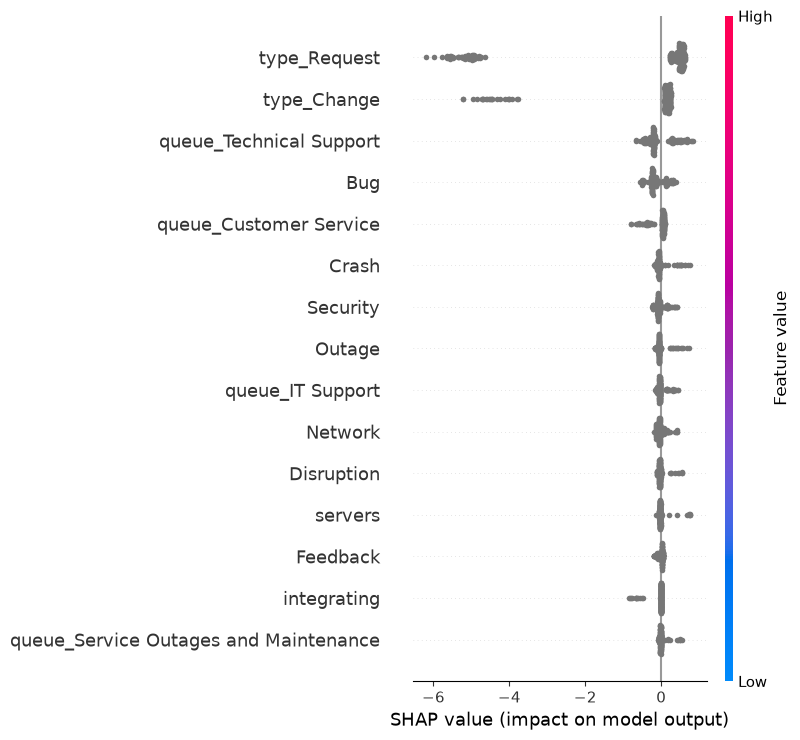

In [29]:
import shap
import numpy as np

sample_idx = np.random.choice(X_val.shape[0], 200, replace=False)
X_val_sample = X_val[sample_idx]

explainer = shap.TreeExplainer(xgb_model_v2)
shap_values = explainer.shap_values(X_val_sample)

feature_names = (
    tfidf.get_feature_names_out().tolist() +
    encoder.get_feature_names_out(cat_cols).tolist() +
    top_tags
)

shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, max_display=15)

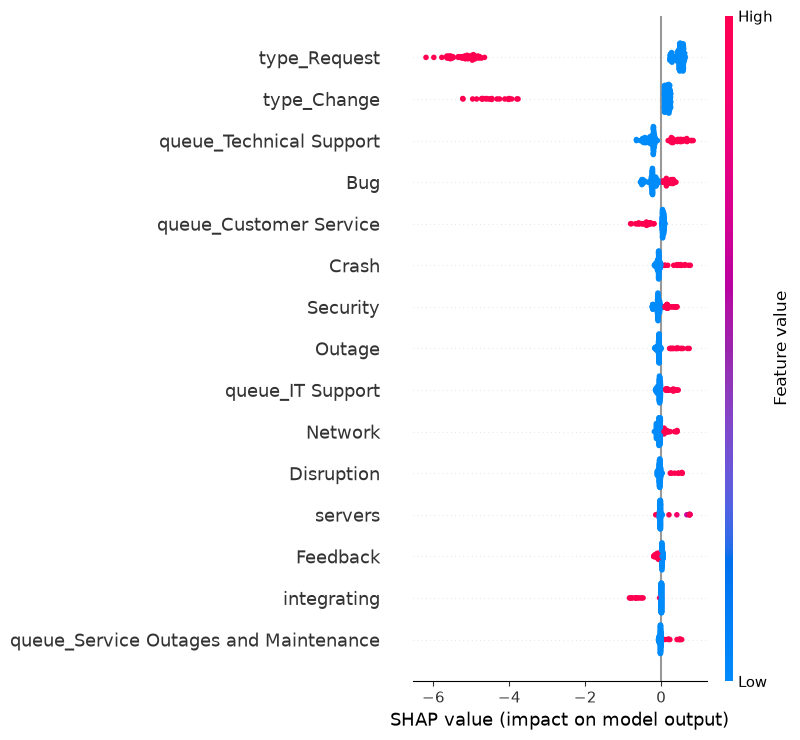

In [30]:
X_val_sample_dense = np.asarray(X_val_sample.todense())
shap.summary_plot(shap_values, X_val_sample_dense, feature_names=feature_names, max_display=15)